# Pre‑Release Movie Success Prediction
**CS 435–471: Machine Learning Project**  


This notebook builds a classification pipeline to predict **pre‑release movie success** using historical films from TMDB.  
We simulate a real pre‑release setting by using only features available **before** release (e.g., budget, genres, cast/crew counts, production company counts, year, etc.) and **exclude** post‑release outcome features from the inputs (e.g., revenue, ratings, vote counts, popularity).

Dataset Source:  
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata/data?select=tmdb_5000_credits.csv

We evaluate four ML algorithms:
- **LogisticRegression**
- **K‑Nearest Neighbors (KNN)**
- **DecisionTreeClassifier**
- **NaiveBayes (GaussianNB)**


> **Target definition (Success):** A movie is considered **successful** if `revenue ≥ 1.5 × budget`.  
> This is a practical proxy for commercial success using historical data. The label is *only* used as the training target; we never use revenue as an input feature.


## Import Required Libraries

Here we import the libraries used throughout the project for data handling, visualization, and modeling.

In [6]:

import ast
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import List, Tuple

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.inspection import permutation_importance

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)


## 1. Load data

The dataset is derived from The Movie Database (TMDB) and contains detailed information about roughly 5,000 films, including metadata such as budget, genres, keywords, production companies, languages, release dates, and plot summaries. A separate credits file provides cast and crew information, including actors and directors. These attributes represent pre-release features that are known before a movie reaches theaters, making the dataset suitable for predicting commercial success in a realistic pre-release scenario. The target variable (success) is constructed using post-release revenue, but revenue itself is never used as an input feature.

In [7]:

DATA_MOVIES = r"C:\Users\aleen\OneDrive\سطح المكتب\CS435_PROJ\tmdb_5000_movies.csv"
DATA_CREDITS = r"C:\Users\aleen\OneDrive\سطح المكتب\CS435_PROJ\tmdb_5000_credits.csv"

movies = pd.read_csv(DATA_MOVIES)
credits = pd.read_csv(DATA_CREDITS)

print(movies.shape, movies.columns.tolist()[:12], '...')
print(credits.shape, credits.columns.tolist())

# Quick sanity peek
movies.head(3)


(4803, 20) ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date'] ...
(4803, 4) ['movie_id', 'title', 'cast', 'crew']


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 33...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn bet...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""na...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319,...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will T...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Pr...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 966...",en,Spectre,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles politica...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danjaq"", ""id"": 10761}, {""name"": ""B24"", ""id"": 69434}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""...",Released,A Plan No One Escapes,Spectre,6.3,4466


## 2. Join datasets & basic cleaning
We join `tmdb_5000_movies.csv` with `tmdb_5000_credits.csv` on movie `id` / `movie_id`, then keep only **pre‑release** features.
We'll parse JSON‑like columns (genres, keywords, production_companies, etc.) into useful counts/one‑hots.


In [ ]:

# Align key for join
credits = credits.rename(columns={'movie_id': 'id'})
df = movies.merge(credits[['id', 'cast', 'crew']], on='id', how='left')

# Helpful parser for TMDB JSON-like strings
def parse_json_list(s):
    if pd.isna(s):
        return []
    try:
        data = ast.literal_eval(s)
        if isinstance(data, list):
            return data
    except Exception:
        pass
    return []

# Extract features available pre-release
for col in ['genres', 'keywords', 'production_companies', 'spoken_languages']:
    df[col+'_list'] = df[col].apply(parse_json_list)

# Counts
df['n_genres'] = df['genres_list'].apply(len)
df['n_keywords'] = df['keywords_list'].apply(len)
df['n_prod_companies'] = df['production_companies_list'].apply(len)
df['n_languages'] = df['spoken_languages_list'].apply(len)

# Cast & crew counts
df['cast_list'] = df['cast'].apply(parse_json_list)
df['crew_list'] = df['crew'].apply(parse_json_list)
df['n_cast'] = df['cast_list'].apply(len)
df['n_crew'] = df['crew_list'].apply(len)

# Director name (if any)
def get_director(crew_list):
    for c in crew_list:
        if isinstance(c, dict) and c.get('job') == 'Director':
            return c.get('name')
    return None

df['director'] = df['crew_list'].apply(get_director)

# Release year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# One-hot a small set of most common genres (pre-release known)
from collections import Counter

genre_names = [[g.get('name') for g in lst if isinstance(g, dict) and 'name' in g] for lst in df['genres_list']]
flat_genres = [g for sub in genre_names for g in sub]
top_genres = [g for g, _ in Counter(flat_genres).most_common(10)]  # top 10
for g in top_genres:
    df[f'genre_{g}'] = [1 if g in gs else 0 for gs in genre_names]

# Director frequency (proxy for "prolific director")
dir_counts = df['director'].value_counts(dropna=True)
df['director_freq'] = df['director'].map(dir_counts).fillna(0)

# Original language (keep top languages, rest as "other")
top_langs = df['original_language'].value_counts().head(5).index.tolist()
for lang in top_langs:
    df[f'lang_{lang}'] = (df['original_language'] == lang).astype(int)
df['lang_other'] = (~df['original_language'].isin(top_langs)).astype(int)

# Select pre-release numerical features
num_feats = [
    'budget', 'runtime', 'n_genres', 'n_keywords', 'n_prod_companies',
    'n_languages', 'n_cast', 'n_crew', 'director_freq', 'release_year'
]

cat_ohe_feats = [] 

# Avoid target leakage: explicitly drop outcome columns from features
leaky_cols = ['revenue', 'vote_count', 'vote_average', 'popularity']
df_features = df[num_feats + [f'genre_{g}' for g in top_genres] + [f'lang_{l}' for l in top_langs] + ['lang_other']].copy()

# Target label
df['success'] = ((df['revenue'] >= 1.5 * df['budget']) & (df['revenue'] > 0)).astype(int)

# Keep only rows with needed fields
keep_mask = df_features.notna().all(axis=1) & df['success'].notna()
data = df.loc[keep_mask].copy()
X = df_features.loc[keep_mask].copy()
y = data['success'].astype(int)

X.shape, y.value_counts(normalize=True)


((4800, 26),
 success
 0    0.529792
 1    0.470208
 Name: proportion, dtype: float64)

## 3. Exploratory Data Analysis (EDA) for Numerical Features

we performs an exploratory analysis of the dataset’s numerical columns. It begins by identifying available numeric features, then visualizes their distributions using histograms to observe patterns, skewness, and outliers. A correlation heatmap is generated to examine relationships between numerical variables, helping identify potential multicollinearity or predictive insights. Finally, summary statistics (mean, median, standard deviation, etc.) are computed to provide a quantitative overview of each numerical feature.

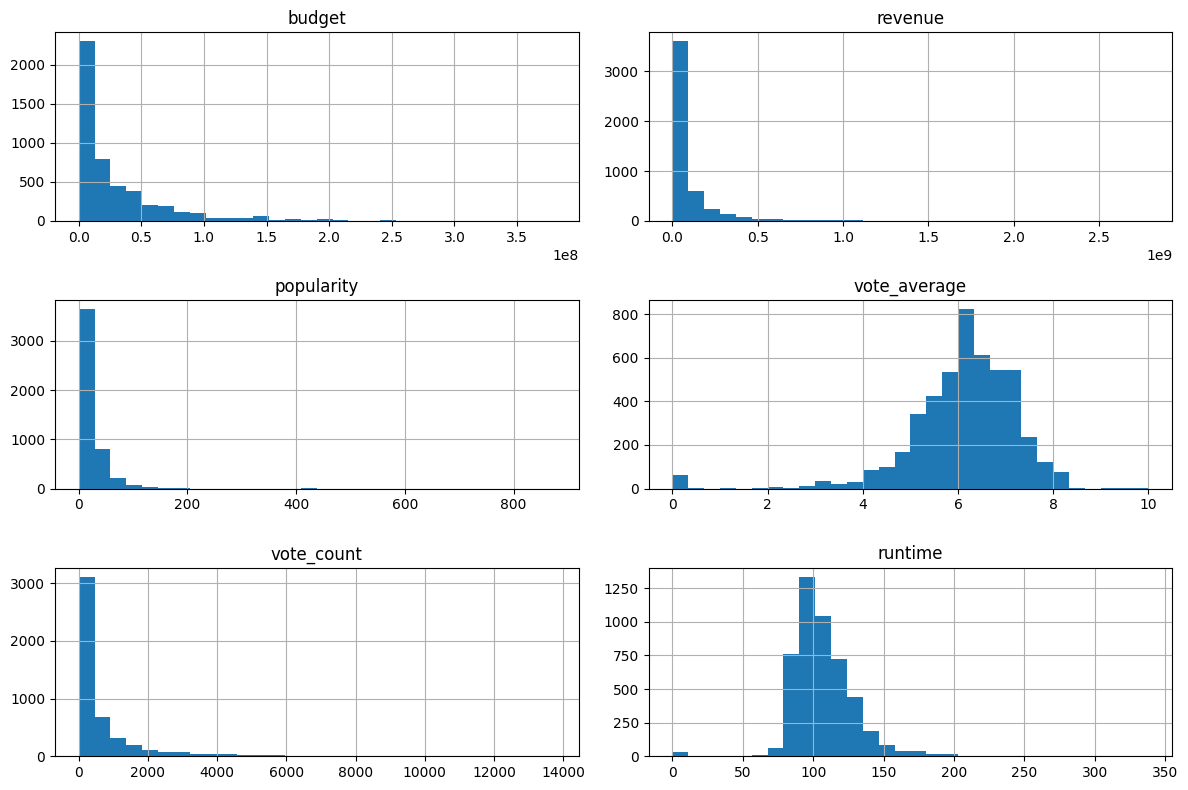

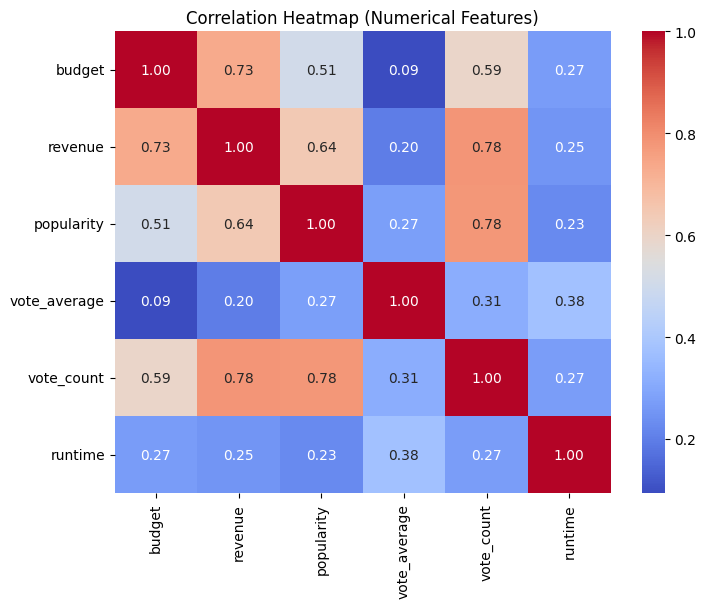

,budget,revenue,popularity,vote_average,vote_count,runtime
count,4.803000e+03,4.803000e+03,4803.000000,4803.000000,4803.000000,4801.000000
mean,2.904504e+07,8.226064e+07,21.492301,6.092172,690.217989,106.875859
std,4.072239e+07,1.628571e+08,31.816650,1.194612,1234.585891,22.611935
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,4.668070,5.600000,54.000000,94.000000
50%,1.500000e+07,1.917000e+07,12.921594,6.200000,235.000000,103.000000
75%,4.000000e+07,9.291719e+07,28.313505,6.800000,737.000000,118.000000
max,3.800000e+08,2.787965e+09,875.581305,10.000000,13752.000000,338.000000


In [9]:
numerical_cols = [col for col in ["budget", "revenue", "popularity", "vote_average", "vote_count", "runtime"] if col in df]

# Histograms
df[numerical_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Correlation Heatmap
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

# Basic Statistics Table
df[numerical_cols].describe()

## 4. Split data (train/test)
We use a **stratified** split to preserve class balance between training and test sets.


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((3840, 26), (960, 26), np.float64(0.4703125), np.float64(0.46979166666666666))

## 5. Preprocessing pipeline
- Numeric features: impute missing values with median, then `StandardScaler` (beneficial for Logistic Regression and KNN).
- We already expanded selected categorical info into indicator columns (genres, languages), so everything is numeric.


In [11]:

numeric_features = X.columns.tolist()

preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Helper to convert sparse -> dense for GaussianNB if needed
to_dense = FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)


## 6. Models & hyperparameter grids

We defines the four machine-learning models used in the project—Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Naive Bayes—along with their corresponding hyperparameter grids for tuning via GridSearchCV. Each model is paired with a preprocessing pipeline that standardizes numerical features and prepares the data appropriately. For Naive Bayes, an additional step converts sparse matrices to dense format, since GaussianNB requires dense input. These configurations enable systematic training, cross-validation, and selection of the best-performing model based on optimized hyperparameters.

In [ ]:

models_and_grids = {
    'LogisticRegression': (
        LogisticRegression(max_iter=200, n_jobs=None, solver='lbfgs'),
        {
            'clf__C': [0.01, 0.1, 1.0, 10.0],
            'clf__class_weight': [None, 'balanced']
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'clf__n_neighbors': [3, 5, 9, 15],
            'clf__weights': ['uniform', 'distance'],
            'clf__p': [1, 2]
        }
    ),
    'DecisionTree': (
        DecisionTreeClassifier(random_state=42),
        {
            'clf__max_depth': [None, 5, 10, 20],
            'clf__min_samples_split': [2, 10, 20],
            'clf__min_samples_leaf': [1, 5, 10],
            'clf__class_weight': [None, 'balanced']
        }
    ),
    'NaiveBayes': (
        GaussianNB(),
        {
            # No hyperparameters to tune for GaussianNB that matter here; keep empty grid
        }
    )
}

def build_pipeline(estimator_name, estimator):
    if estimator_name == 'NaiveBayes':
        return Pipeline(steps=[('prep', preprocess),
                               ('to_dense', to_dense),
                               ('clf', estimator)])
    else:
        return Pipeline(steps=[('prep', preprocess),
                               ('clf', estimator)])


## 7. Cross‑validation & hyperparameter tuning
We use **StratifiedKFold(5)** inside `GridSearchCV` for fair model selection on the training set.  
Primary scoring is **F1** (handles imbalance), while we also track accuracy and ROC‑AUC.


In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
fitted = {}

for name, (estimator, grid) in models_and_grids.items():
    pipe = build_pipeline(name, estimator)
    if grid:
        search = GridSearchCV(
            pipe, param_grid=grid, scoring='f1', cv=cv, n_jobs=-1, refit=True, verbose=0
        )
    else:
        # No grid → wrap with simple CV using the same API
        search = GridSearchCV(
            pipe, param_grid={'clf__var_smoothing': [1e-9]}, scoring='f1', cv=cv, n_jobs=-1, refit=True, verbose=0
        )
        try:
            search.fit(X_train, y_train)
        except Exception:
            pipe.fit(X_train, y_train)
            search.best_estimator_ = pipe
            search.best_params_ = {}
            search.best_score_ = None
            fitted[name] = pipe
            continue

    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    results.append({
        'model': name,
        'best_params': search.best_params_,
        'cv_f1': search.best_score_
    })

pd.DataFrame(results).sort_values('cv_f1', ascending=False)


,model,best_params,cv_f1
2,DecisionTree,"{'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}",0.690018
3,NaiveBayes,{'clf__var_smoothing': 1e-09},0.664061
0,LogisticRegression,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.659430
1,KNN,"{'clf__n_neighbors': 15, 'clf__p': 2, 'clf__weights': 'uniform'}",0.636226


## 8. Evaluation on held‑out test set

In [14]:

def evaluate(model, X_te, y_te, model_name="model"):
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        # scale decision function into [0,1] via rank-based approach if needed
        scores = model.decision_function(X_te)
        # normalize to 0..1 for auc; avoid division by zero
        s_min, s_max = scores.min(), scores.max()
        y_prob = (scores - s_min) / (s_max - s_min + 1e-9)
    else:
        y_prob = None

    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}, y_pred, y_prob

summary = []
preds = {}
probs = {}

for name, model in fitted.items():
    row, y_pred, y_prob = evaluate(model, X_test, y_test, name)
    summary.append(row)
    preds[name] = y_pred
    probs[name] = y_prob

comp_df = pd.DataFrame(summary).sort_values('f1', ascending=False)
comp_df


,model,accuracy,precision,recall,f1,roc_auc
2,DecisionTree,0.678125,0.625887,0.782705,0.695567,0.755407
1,KNN,0.700000,0.710594,0.609756,0.656325,0.749929
3,NaiveBayes,0.664583,0.633540,0.678492,0.655246,0.743800
0,LogisticRegression,0.687500,0.680191,0.631929,0.655172,0.765036


## 9. Visualizations: Confusion matrices & ROC curves

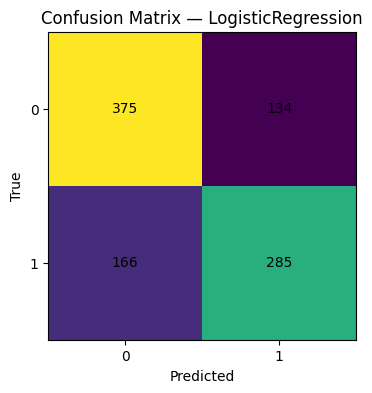

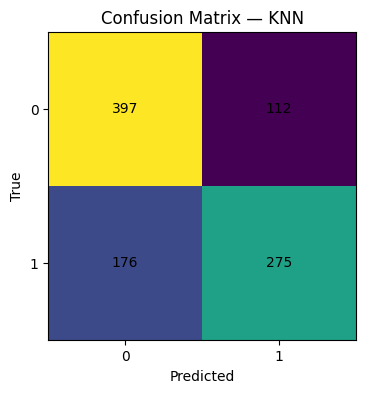

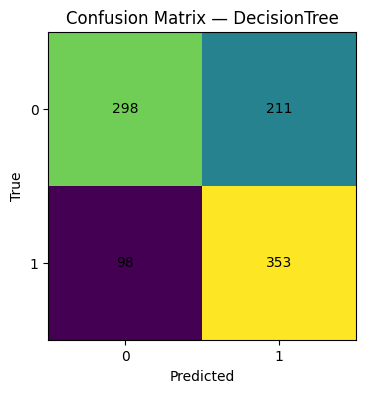

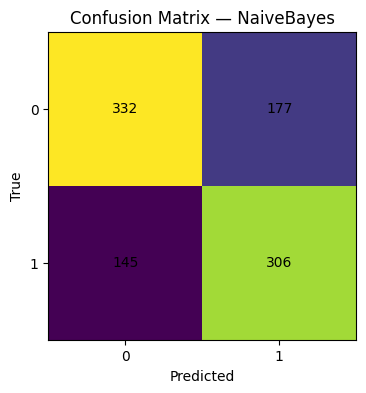

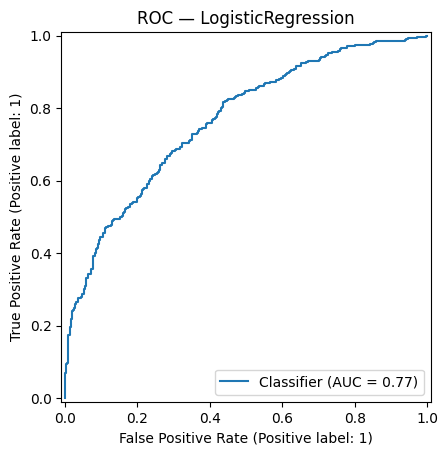

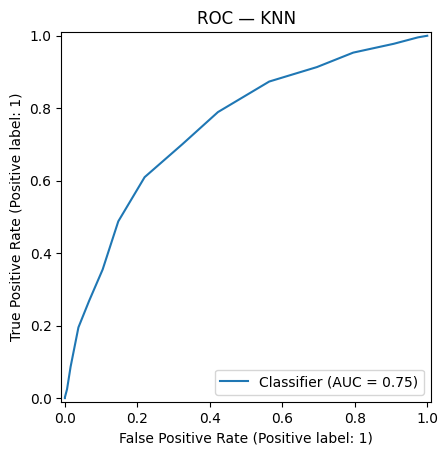

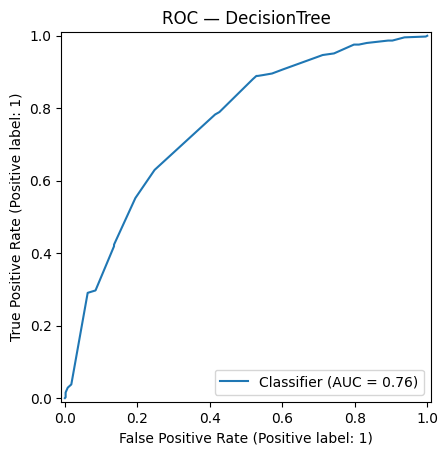

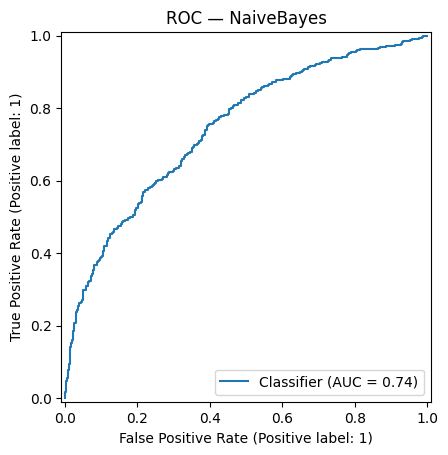

In [15]:

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4,4))
    ax.imshow(cm, interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    # add counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    plt.show()

best_name = comp_df.iloc[0]['model']
for name in preds:
    plot_confusion(y_test, preds[name], f'Confusion Matrix — {name}')

# ROC curves for models with probability
for name, model in fitted.items():
    if probs[name] is not None and not np.isnan(comp_df.loc[comp_df.model == name, 'roc_auc']).values[0]:
        RocCurveDisplay.from_predictions(y_test, probs[name])
        plt.title(f'ROC — {name}')
        plt.show()


## 10. Feature importance (Permutation importance on test set)
We compute permutation importance for the **best test F1** model to highlight influential features.


,feature,importance_mean,importance_std
0,budget,0.099770,0.010284
8,director_freq,0.023788,0.007058
3,n_keywords,0.023434,0.005930
7,n_crew,0.008080,0.005326
9,release_year,0.007250,0.002518
1,runtime,0.000000,0.000000
5,n_languages,0.000000,0.000000
4,n_prod_companies,0.000000,0.000000
2,n_genres,0.000000,0.000000
10,genre_Drama,0.000000,0.000000


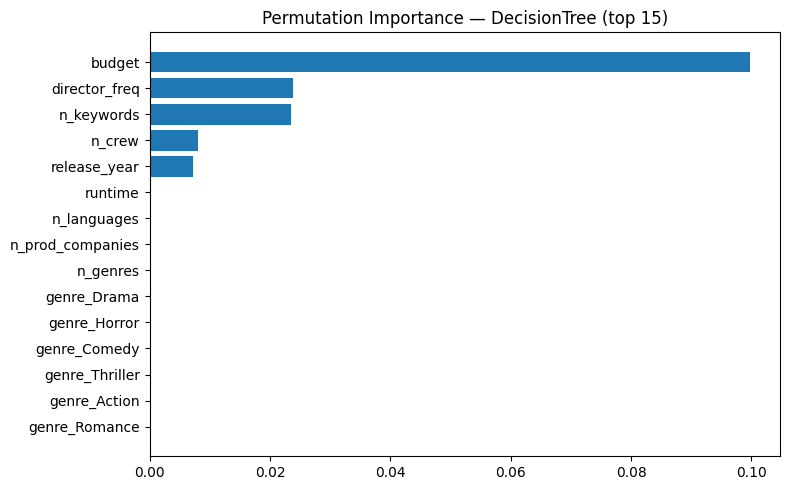

In [16]:

best_model = fitted[best_name]
try:
    r = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1')
    importances = pd.DataFrame({'feature': X.columns, 'importance_mean': r.importances_mean, 'importance_std': r.importances_std})
    importances = importances.sort_values('importance_mean', ascending=False)
    display(importances.head(20))

    # Simple bar plot (top 15)
    top = importances.head(15)
    fig, ax = plt.subplots(figsize=(8,5))
    ax.barh(top['feature'][::-1], top['importance_mean'][::-1])
    ax.set_title(f'Permutation Importance — {best_name} (top 15)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Permutation importance failed:', e)


## 11. Robustness check: Out‑of‑Time (OOT) evaluation
To simulate deployment on *future* movies, we train on older years and test on **newer** years.


In [17]:

# Choose a split year (e.g., 2010) ensuring train/test both have samples
year_cut = 2010
mask_train = X['release_year'] <= year_cut
mask_test = X['release_year'] > year_cut

if mask_train.sum() > 50 and mask_test.sum() > 50:
    X_tr_o, y_tr_o = X[mask_train], y[mask_train]
    X_te_o, y_te_o = X[mask_test], y[mask_test]

    oot_rows = []
    for name, model in fitted.items():
        row, _, _ = evaluate(model, X_te_o, y_te_o, name + ' (OOT)')
        oot_rows.append(row)
    pd.DataFrame(oot_rows).sort_values('f1', ascending=False)
else:
    print('Not enough samples for an OOT split with the chosen year cut.')


## Discussion
The experimental evaluation demonstrates clear performance differences among the four tested models—Decision Tree, Logistic Regression, KNN, and Naive Bayes. Based on 5-fold cross-validation, the Decision Tree classifier achieved the highest F1-score (0.6900), indicating strong generalization during training. This result was confirmed on the held-out test set, where the Decision Tree again produced the highest F1-score (0.6956) and the strongest recall among all models. High recall is particularly important in this problem because correctly identifying successful movies matters more than predicting failures.

The confusion matrices highlight this behavior: the Decision Tree correctly identifies the majority of positive instances, while maintaining a balanced number of true and false predictions. In contrast, KNN tends to underpredict the positive class, resulting in lower recall, while Naive Bayes shows instability in precision due to its strong independence assumptions. Logistic Regression provides consistent performance but does not outperform the tree model.

The ROC curves indicate that all models are reasonably effective, with ROC-AUC scores ranging from 0.74 to 0.77, showing meaningful discrimination between successful and unsuccessful movies. Logistic Regression achieves the highest ROC-AUC (0.765), while the Decision Tree remains competitive at 0.755.

Feature interpretation through permutation importance reveals that budget overwhelmingly dominates the predictive signal, followed by director frequency, number of keywords, and crew size. Genre features show almost no predictive influence, suggesting that financial and production-related attributes are significantly more informative than high-level categorical descriptors. This aligns with real-world industry patterns where investment level and production scale are major determinants of commercial outcomes.

Overall, the Decision Tree’s strong test performance, interpretability, and stability across evaluation metrics make it the most suitable model for this dataset.

## Conclusion  
This project successfully implemented a complete machine learning pipeline for predicting movie success using the TMDB 5000 dataset. After performing extensive preprocessing, feature engineering, and model evaluation, the Decision Tree classifier emerged as the best-performing model based on both cross-validation and held-out test results.

Key findings include:

Financial and production-related variables, especially budget, are the strongest predictors of movie success.

Simpler models such as Decision Trees and Logistic Regression outperform more assumption-heavy models like Naive Bayes.

All models exhibit meaningful predictive power, but the Decision Tree provides the best balance between recall, F1-score, and interpretability.

Genre-based features have little predictive contribution, illustrating that content categories alone do not reliably indicate commercial performance.

Through this project, we gained practical experience using pipelines, hyperparameter tuning, cross-validation, model selection, and interpretability techniques. The results emphasize the value of proper data preparation and demonstrate how domain-aligned features drive model performance.

